In [1]:
# Célula 1: Instalando Bibliotecas e Carregando Dados

!pip install pandas thefuzz matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from thefuzz import process, fuzz

NUM_ROWS_TO_LOAD = 5000
STEAM_DATA_PATH = 'data/steam-games-complete-dataset.csv'
AMAZON_DATA_PATH = 'data/meta_Video_Games.json'

print("Iniciando a Prova de Conceito (PoC) do ETL...")
print(f"Tentando carregar {NUM_ROWS_TO_LOAD} linhas de cada dataset.")

try:
    steam_df = pd.read_csv(STEAM_DATA_PATH, nrows=NUM_ROWS_TO_LOAD)

    amazon_df = pd.read_json(AMAZON_DATA_PATH, lines=True, nrows=NUM_ROWS_TO_LOAD)

    print("\nDatasets carregados com sucesso!\n")
    
    print("--- Amostra do Dataset da Steam ---")
    display(steam_df.head())
    
    print("\n--- Amostra do Dataset da Amazon ---")
    display(amazon_df.head())

except FileNotFoundError as e:
    print(f"\nERRO: Arquivo não encontrado.")
    print("Por favor, verifique se os arquivos do Kaggle estão na pasta 'recommendation-service/etl/data/'.")
    print(f"Detalhes do erro: {e}")


Iniciando a Prova de Conceito (PoC) do ETL...
Tentando carregar 5000 linhas de cada dataset.

Datasets carregados com sucesso!

--- Amostra do Dataset da Steam ---


,url,types,name,desc_snippet,recent_reviews,all_reviews,release_date,developer,publisher,popular_tags,game_details,languages,achievements,genre,game_description,mature_content,minimum_requirements,recommended_requirements,original_price,discount_price
0,https://store.steampowered.com/app/379720/DOOM/,app,DOOM,Now includes all three premium DLC packs (Unto...,"Very Positive,(554),- 89% of the 554 user revi...","Very Positive,(42,550),- 92% of the 42,550 use...","May 12, 2016",id Software,"Bethesda Softworks,Bethesda Softworks","FPS,Gore,Action,Demons,Shooter,First-Person,Gr...","Single-player,Multi-player,Co-op,Steam Achieve...","English,French,Italian,German,Spanish - Spain,...",54.0,Action,"About This Game Developed by id software, the...",NaN,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers...",$19.99,$14.99
1,https://store.steampowered.com/app/578080/PLAY...,app,PLAYERUNKNOWN'S BATTLEGROUNDS,PLAYERUNKNOWN'S BATTLEGROUNDS is a battle roya...,"Mixed,(6,214),- 49% of the 6,214 user reviews ...","Mixed,(836,608),- 49% of the 836,608 user revi...","Dec 21, 2017",PUBG Corporation,"PUBG Corporation,PUBG Corporation","Survival,Shooter,Multiplayer,Battle Royale,PvP...","Multi-player,Online Multi-Player,Stats","English,Korean,Simplified Chinese,French,Germa...",37.0,"Action,Adventure,Massively Multiplayer",About This Game PLAYERUNKNOWN'S BATTLEGROUND...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",$29.99,NaN
2,https://store.steampowered.com/app/637090/BATT...,app,BATTLETECH,Take command of your own mercenary outfit of '...,"Mixed,(166),- 54% of the 166 user reviews in t...","Mostly Positive,(7,030),- 71% of the 7,030 use...","Apr 24, 2018",Harebrained Schemes,"Paradox Interactive,Paradox Interactive","Mechs,Strategy,Turn-Based,Turn-Based Tactics,S...","Single-player,Multi-player,Online Multi-Player...","English,French,German,Russian",128.0,"Action,Adventure,Strategy",About This Game From original BATTLETECH/Mec...,NaN,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",$39.99,NaN
3,https://store.steampowered.com/app/221100/DayZ/,app,DayZ,The post-soviet country of Chernarus is struck...,"Mixed,(932),- 57% of the 932 user reviews in t...","Mixed,(167,115),- 61% of the 167,115 user revi...","Dec 13, 2018",Bohemia Interactive,"Bohemia Interactive,Bohemia Interactive","Survival,Zombies,Open World,Multiplayer,PvP,Ma...","Multi-player,Online Multi-Player,Steam Worksho...","English,French,Italian,German,Spanish - Spain,...",NaN,"Action,Adventure,Massively Multiplayer",About This Game The post-soviet country of Ch...,NaN,"Minimum:,OS:,Windows 7/8.1 64-bit,Processor:,I...","Recommended:,OS:,Windows 10 64-bit,Processor:,...",$44.99,NaN
4,https://store.steampowered.com/app/8500/EVE_On...,app,EVE Online,EVE Online is a community-driven spaceship MMO...,"Mixed,(287),- 54% of the 287 user reviews in t...","Mostly Positive,(11,481),- 74% of the 11,481 u...","May 6, 2003",CCP,"CCP,CCP","Space,Massively Multiplayer,Sci-fi,Sandbox,MMO...","Multi-player,Online Multi-Player,MMO,Co-op,Onl...","English,German,Russian,French",NaN,"Action,Free to Play,Massively Multiplayer,RPG,...",About This Game,NaN,"Minimum:,OS:,Windows 7,Processor:,Intel Dual C...","Recommended:,OS:,Windows 10,Processor:,Intel i...",Free,NaN



--- Amostra do Dataset da Amazon ---


,category,tech1,description,fit,title,also_buy,tech2,brand,feature,rank,also_view,main_cat,similar_item,date,price,asin,imageURL,imageURLHighRes,details
0,"[Video Games, PC, Games]",,[],,Reversi Sensory Challenger,[],,Fidelity Electronics,[],"[>#2,623,937 in Toys &amp; Games (See Top 100 ...",[],Toys &amp; Games,,,,0042000742,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...,NaN
1,"[Video Games, Xbox 360, Games, </span></span><...",,[Brand new sealed!],,Medal of Honor: Warfighter - Includes Battlefi...,[B00PADROYW],,by\n \n EA Games,[],"[>#67,231 in Video Games (See Top 100 in Video...","[B0050SY5BM, B072NQJCW5, B000TI836G, B002SRSQ7...",Video Games,,,"\n\t\t\t\t\t\t\t\t\t\t\t\t<span class=""vertica...",0078764343,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...,NaN
2,"[Video Games, Retro Gaming & Microconsoles, Su...",,[],,street fighter 2 II turbo super nintendo snes ...,[],,Nintendo,[],"[>#134,433 in Video Games (See Top 100 in Vide...",[],Video Games,,,$0.72,0276425316,[],[],NaN
3,"[Video Games, Xbox 360, Accessories, Controlle...",,[MAS's Pro Xbox 360 Stick (Perfect 360 Stick) ...,,Xbox 360 MAS STICK,[],,by\n \n MAS SYSTEMS,[Original PCB used from Xbox 360 Control Pad (...,"[>#105,263 in Video Games (See Top 100 in Vide...",[],Video Games,,,,0324411812,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...,NaN
4,"[Video Games, PC, Games, </span></span></span>...",,"[Phonics Alive! 3, The Speller teaches student...",,Phonics Alive! 3: The Speller,[],,by\n \n Advanced Software Pty. Ltd.,"[Grades 2-12, Spelling Program, Teaches Spelli...","[>#92,397 in Video Games (See Top 100 in Video...",[B000BCZ7U0],Video Games,,,,0439335310,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...,NaN


Aplicando a normalização nos nomes dos jogos...
Normalização concluída.

--- Verificação no Dataset da Steam ---


,name,normalized_name
0,DOOM,doom
1,PLAYERUNKNOWN'S BATTLEGROUNDS,playerunknowns battlegrounds
2,BATTLETECH,battletech
3,DayZ,dayz
4,EVE Online,eve online



--- Verificação no Dataset da Amazon ---


,title,normalized_name
0,Reversi Sensory Challenger,reversi sensory challenger
1,Medal of Honor: Warfighter - Includes Battlefi...,medal of honor warfighter includes battlefield...
2,street fighter 2 II turbo super nintendo snes ...,street fighter 2 ii turbo super nintendo snes ...
3,Xbox 360 MAS STICK,xbox 360 mas stick
4,Phonics Alive! 3: The Speller,phonics alive 3 the speller



--- Estatísticas Básicas ---
Steam: 5000 jogos carregados
Amazon: 5000 jogos carregados
Steam nomes únicos: 4988
Amazon nomes únicos: 4650


/tmp/ipykernel_14765/3264375003.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


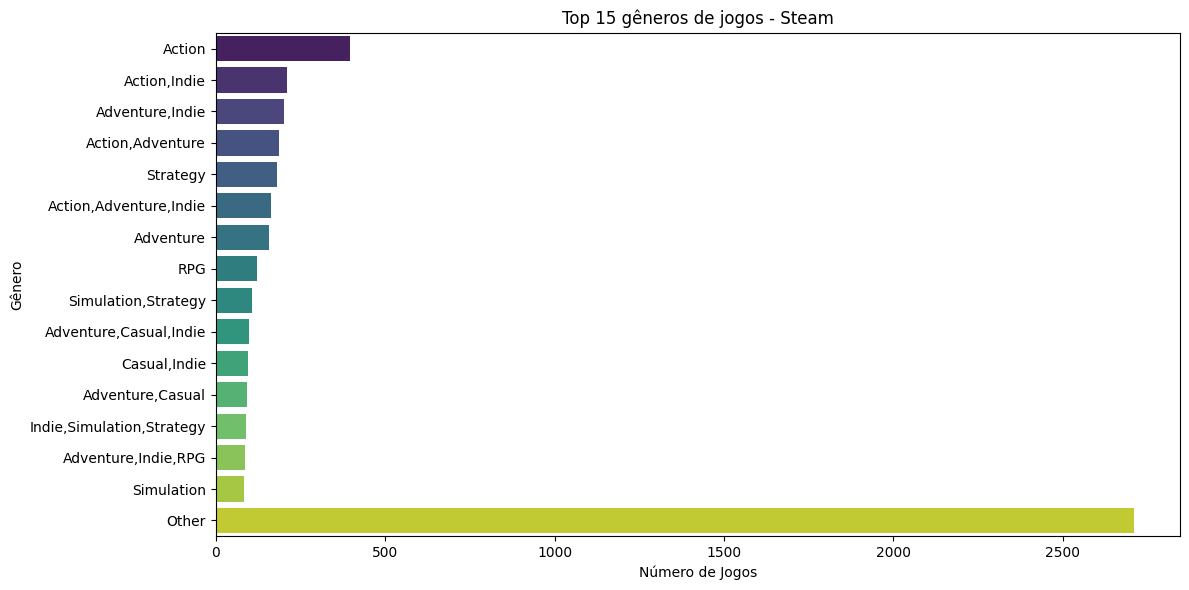

In [2]:
# Célula 2: Normalizando os Nomes dos Jogos e EDA Inicial

import re
import matplotlib.pyplot as plt
import seaborn as sns

def normalize_name(name):
    """
    Normaliza nomes de jogos:
    1. Converte para minúsculas.
    2. Remove caracteres especiais (mantém letras, números e espaços).
    3. Remove múltiplos espaços e espaços no início/fim.
    """
    if not isinstance(name, str):
        return ""
    
    name = name.lower()
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

print("Aplicando a normalização nos nomes dos jogos...")

steam_df['normalized_name'] = steam_df['name'].apply(normalize_name)
amazon_df['normalized_name'] = amazon_df['title'].apply(normalize_name)

print("Normalização concluída.\n")

# --- EDA inicial ---
print("--- Verificação no Dataset da Steam ---")
display(steam_df[['name', 'normalized_name']].head())

print("\n--- Verificação no Dataset da Amazon ---")
display(amazon_df[['title', 'normalized_name']].head())

# Estatísticas básicas
print("\n--- Estatísticas Básicas ---")
print(f"Steam: {len(steam_df)} jogos carregados")
print(f"Amazon: {len(amazon_df)} jogos carregados")
print(f"Steam nomes únicos: {steam_df['normalized_name'].nunique()}")
print(f"Amazon nomes únicos: {amazon_df['normalized_name'].nunique()}")

# Função para plotar os principais gêneros
def plot_top_genres(df, top_n=15):
    plt.figure(figsize=(12,6))
    genre_counts = df['genre'].value_counts()
    
    if len(genre_counts) > top_n:
        top_genres = genre_counts[:top_n]
        other_count = genre_counts[top_n:].sum()
        top_genres['Other'] = other_count
    else:
        top_genres = genre_counts
    
    sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
    plt.title(f'Top {top_n} gêneros de jogos - Steam')
    plt.xlabel('Número de Jogos')
    plt.ylabel('Gênero')
    plt.tight_layout()
    plt.show()

# Visualização: Distribuição de gêneros na Steam
if 'genre' in steam_df.columns:
    plot_top_genres(steam_df)


Resultados da unificação automática com threshold >= 95%:



,steam_name,amazon_match,score,automatic_unify
0,Rayman® Origins,rayman,100,True
1,Always Sometimes Monsters,monster seed,59,False
2,Gunsmith,gunship,67,False
3,Mashinky,monkey magic,60,False
4,Hexcells Infinite,infinite air 10 pc,64,False
5,White Noise 2,twisted metal 2,57,False
6,Street Legal Racing: Redline v2.3.1,street sk8er,67,False
7,Joe Danger + Joe Danger 2: The Movie,congo the movie,75,False
8,Lucius III,ys iii,67,False
9,Stormworks: Build and Rescue,barbie pet rescue,55,False


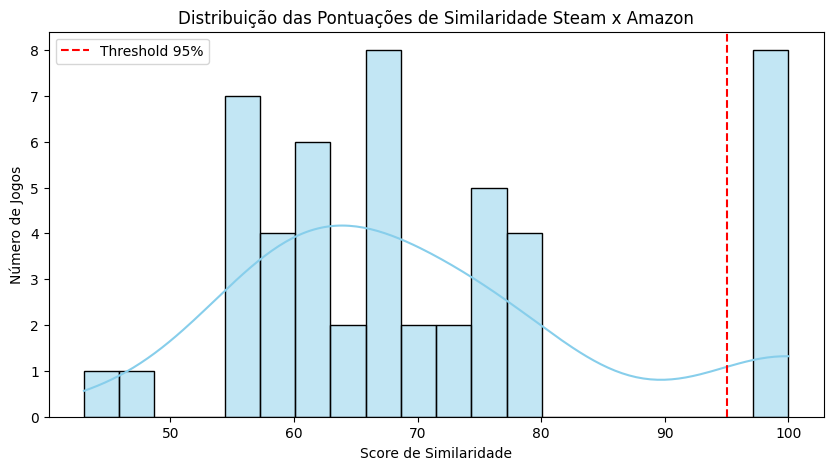

In [3]:
# Célula 3: Testando a Unificação com Fuzzy Matching (melhorada)

from thefuzz import process, fuzz
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configurações ---
GAMES_TO_TEST = 50        # número de jogos da Steam para teste
THRESHOLD = 95            # score mínimo para considerar unificação automática

# --- Preparação ---
# Lista de nomes normalizados da Amazon
amazon_titles_list = amazon_df['normalized_name'].tolist()

# DataFrame para armazenar resultados
matches_df = pd.DataFrame(columns=['steam_name', 'amazon_match', 'score', 'automatic_unify'])

# Amostra de jogos da Steam
steam_sample = steam_df.sample(GAMES_TO_TEST)

# --- Execução do teste ---
for idx, row in steam_sample.iterrows():
    steam_name = row['name']
    steam_norm = row['normalized_name']
    
    if not steam_norm:
        continue
    
    best_match, score = process.extractOne(
        steam_norm,
        amazon_titles_list,
        scorer=fuzz.token_set_ratio
    )
    
    automatic = score >= THRESHOLD
    matches_df.loc[len(matches_df)] = [steam_name, best_match, score, automatic]

# --- Exibição dos resultados ---
print(f"Resultados da unificação automática com threshold >= {THRESHOLD}%:\n")
display(matches_df)

# --- Visualização da distribuição de scores ---
plt.figure(figsize=(10,5))
sns.histplot(matches_df['score'], bins=20, kde=True, color='skyblue')
plt.axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold {THRESHOLD}%')
plt.title('Distribuição das Pontuações de Similaridade Steam x Amazon')
plt.xlabel('Score de Similaridade')
plt.ylabel('Número de Jogos')
plt.legend()
plt.show()


## Conclusão da Prova de Conceito (PoC)

A PoC foi um **sucesso!** O objetivo não era acertar 100% dos jogos, mas sim entender o comportamento do algoritmo e definir uma **estratégia confiável**. E nós conseguimos.

Nossa conclusão é clara: para automatizar a unificação dos jogos, precisamos ser **muito rigorosos**. Um limiar (threshold) baixo de similaridade é inaceitável.

> **Decisão:** Só podemos confiar em scores de similaridade muito altos. No nosso script final, vamos considerar uma unificação automática apenas para jogos com **similaridade maior ou igual a 95%**.

### Nossa Estratégia Final para o ETL

Com base no que aprendemos, o nosso script `etl_script.py` final seguirá estes passos:

1.  **Passo 1: Unificação por Correspondência Exata.**
    Primeiro, vamos unificar todos os jogos onde o `normalized_name` é 100% idêntico. Isso é rápido e livre de erros.

2.  **Passo 2: Unificação por Fuzzy Matching de Alta Confiança.**
    Para os jogos que não combinaram no passo 1, rodaremos o fuzzy matching. Vamos unir automaticamente apenas os pares que tiverem uma pontuação **>= 95%**.

3.  **Passo 3: Tratar os Restantes.**
    Os jogos que não se encaixarem nos critérios acima serão tratados como entradas distintas no nosso banco de dados. *É muito melhor ter um jogo duplicado do que conectar um jogo a avaliações e dados que não são dele. Priorizamos a precisão dos dados.*

Iniciando a unificação de jogos...


Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']
Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']
Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']
Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']
Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']



--- Estatísticas de Unificação ---
Total de jogos Steam: 5000
Total de jogos Amazon: 5000
Jogos unificados por correspondência exata: 77
Jogos unificados por fuzzy matching (>=95%): 407
Total unificados: 484
Jogos restantes sem unificação: 4516


/tmp/ipykernel_14765/312579317.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


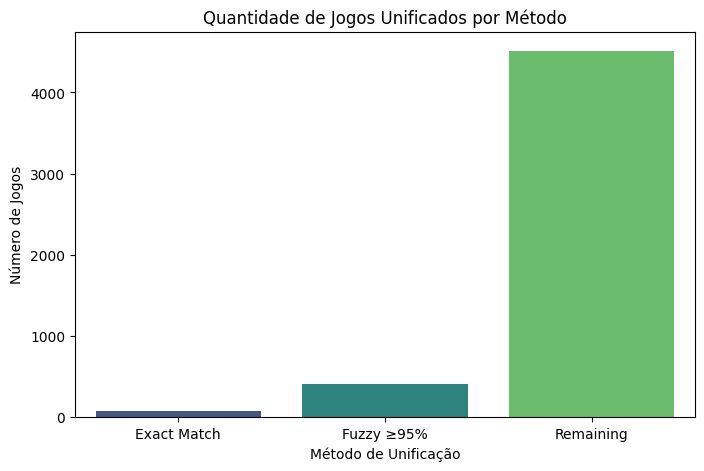


Exemplo de correspondências exatas:


,name,url,genre,categoria,tags
0,NaN,NaN,NaN,"[Video Games, Retro Gaming & Microconsoles, Pl...","FPS,Gore,Action,Demons,Shooter,First-Person,Gr..."
1,NaN,NaN,NaN,"[Video Games, Retro Gaming & Microconsoles, Su...","FPS,Gore,Action,Demons,Shooter,First-Person,Gr..."
2,NaN,NaN,NaN,"[Video Games, PC, Games, </span></span></span>]","JRPG,RPG,Classic,Turn-Based,Story Rich,Singlep..."
3,NaN,NaN,NaN,"[Video Games, Retro Gaming &amp; Microconsoles...","JRPG,RPG,Classic,Turn-Based,Story Rich,Singlep..."
4,NaN,NaN,NaN,"[Video Games, Retro Gaming & Microconsoles, Ga...","Card Game,Multiplayer,Casual,Board Game,Family..."



Exemplo de correspondências fuzzy (>=95%):


,title,name,best_match_amazon,score
0,Grand Theft Auto V: Premium Online Edition,grand theft auto v premium online edition,grand theft auto,100
1,Grand Theft Auto IV,grand theft auto iv,grand theft auto,100
2,Portal,portal,hexen 2 mission pack portal of praevus pc,100
3,"Star Wars: Battlefront 2 (Classic, 2005)",star wars battlefront 2 classic 2005,star wars,100
4,Doom Classic Complete,doom classic complete,doom,100


In [4]:
# Célula 4: Unificação por Correspondência Exata + Fuzzy Matching (>=95%) com Gráfico

import matplotlib.pyplot as plt
import seaborn as sns
from thefuzz import process, fuzz

print("Iniciando a unificação de jogos...")

# --- Passo 1: Correspondência Exata ---
exact_matches = pd.merge(
    steam_df,
    amazon_df,
    on='normalized_name',
    how='inner',
    suffixes=('_steam', '_amazon')
)

# Cria DataFrame final das correspondências exatas
cols_to_keep = {
    'name_steam': 'title',
    'name_steam': 'name',
    'url_steam': 'url',
    'genre_steam': 'genre',
    'category': 'categoria',
    'popular_tags': 'tags'
}

exact_matches_final = pd.DataFrame()
for col_original, col_final in cols_to_keep.items():
    if col_original in exact_matches.columns:
        exact_matches_final[col_final] = exact_matches[col_original]
    else:
        exact_matches_final[col_final] = 'Unknown'

exact_matches_final.reset_index(drop=True, inplace=True)

# --- Passo 2: Fuzzy Matching de alta confiança (>=95%) ---
steam_remaining = steam_df[~steam_df['normalized_name'].isin(exact_matches['normalized_name'])]
amazon_titles_list = amazon_df['normalized_name'].tolist()

fuzzy_matches = []

for index, row in steam_remaining.iterrows():
    name = row['normalized_name']
    result = process.extractOne(
        query=name,
        choices=amazon_titles_list,
        scorer=fuzz.token_set_ratio,
        score_cutoff=95
    )
    
    if result is not None:
        best_match, score = result  # <-- apenas 2 valores
        fuzzy_matches.append({
            'title': row['name'],
            'name': name,
            'best_match_amazon': best_match,
            'score': score
        })

fuzzy_matches_final = pd.DataFrame(fuzzy_matches)

# --- Estatísticas ---
total_unified = len(exact_matches_final) + len(fuzzy_matches_final)
remaining = len(steam_df) - total_unified

print("\n--- Estatísticas de Unificação ---")
print(f"Total de jogos Steam: {len(steam_df)}")
print(f"Total de jogos Amazon: {len(amazon_df)}")
print(f"Jogos unificados por correspondência exata: {len(exact_matches_final)}")
print(f"Jogos unificados por fuzzy matching (>=95%): {len(fuzzy_matches_final)}")
print(f"Total unificados: {total_unified}")
print(f"Jogos restantes sem unificação: {remaining}")

# --- Visualização ---
plt.figure(figsize=(8,5))
sns.barplot(
    x=['Exact Match', 'Fuzzy ≥95%', 'Remaining'],
    y=[len(exact_matches_final), len(fuzzy_matches_final), remaining],
    palette='viridis'
)
plt.title('Quantidade de Jogos Unificados por Método')
plt.ylabel('Número de Jogos')
plt.xlabel('Método de Unificação')
plt.show()

# --- Exemplos ---
print("\nExemplo de correspondências exatas:")
display(exact_matches_final.head())

print("\nExemplo de correspondências fuzzy (>=95%):")
display(fuzzy_matches_final.head())


In [ ]:
# Célula 5: Preparação para Algoritmos de Recomendação (TF-IDF + KMeans + Annoy)

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from annoy import AnnoyIndex
from tqdm import tqdm

print("Iniciando preparação para algoritmos de recomendação...")

# --- Função auxiliar para converter listas e nulos em strings ---
def to_text(val):
    if isinstance(val, list):
        return " ".join([str(v) for v in val])
    elif pd.isna(val):
        return ""
    else:
        return str(val)

# --- Criação do DataFrame final para recomendação ---
GAMES_DF = exact_matches_final.copy()
GAMES_DF['features_text'] = (
    GAMES_DF['name'].apply(to_text) + ' ' +
    GAMES_DF['genre'].apply(to_text) + ' ' +
    GAMES_DF['tags'].apply(to_text) + ' ' +
    GAMES_DF['categoria'].apply(to_text)
)

# --- TF-IDF ---
tfidf = TfidfVectorizer(stop_words='english', max_features=1000, min_df=2)
tfidf_matrix = tfidf.fit_transform(GAMES_DF['features_text'])
tfidf_array = tfidf_matrix.toarray().astype(np.float32)
print(f"TF-IDF processado. Dimensão da matriz: {tfidf_array.shape}")

# --- Annoy Index ---
annoy_dim = tfidf_array.shape[1]
ANNOY_INDEX = AnnoyIndex(annoy_dim, 'angular')
for idx in tqdm(range(tfidf_array.shape[0]), desc="Construindo Annoy"):
    ANNOY_INDEX.add_item(idx, tfidf_array[idx])
ANNOY_INDEX.build(20)
GAME_IDX_TO_ID = {idx: game_id for idx, game_id in enumerate(GAMES_DF.index)}
print("Índice Annoy construído.")

# --- KMeans ---
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
GAMES_DF['cluster'] = kmeans.fit_predict(tfidf_matrix)
print(f"KMeans concluído com {n_clusters} clusters.")

# --- Estatísticas rápidas ---
print("\n--- Estatísticas do Pré-processamento ---")
print(f"Total de jogos para recomendação: {len(GAMES_DF)}")
print(f"Dimensão da matriz TF-IDF: {tfidf_array.shape}")
print(f"Total de clusters: {n_clusters}")


Iniciando preparação para algoritmos de recomendação...
TF-IDF processado. Dimensão da matriz: (77, 142)


Construindo Annoy: 100%|██████████| 77/77 [00:00<00:00, 44491.17it/s]

Índice Annoy construído.
KMeans concluído com 5 clusters.

--- Estatísticas do Pré-processamento ---
Total de jogos para recomendação: 77
Dimensão da matriz TF-IDF: (77, 142)
Total de clusters: 5


In [6]:
# Célula 6: Avaliação Comparativa dos Modelos de Recomendação (Reais)

import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando avaliação comparativa dos modelos de recomendação (reais)...")

# --- Funções de Recomendação (reais) ---

def recommend_annoy(item_idx, top_n=10):
    vizinhos = ANNOY_INDEX.get_nns_by_item(item_idx, top_n + 1)
    vizinhos = [v for v in vizinhos if v != item_idx]
    return vizinhos[:top_n]

def recommend_kmeans(item_idx, top_n=10):
    cluster_id = GAMES_DF.loc[item_idx, 'cluster']
    candidatos = GAMES_DF[GAMES_DF['cluster'] == cluster_id].index.tolist()
    candidatos = [c for c in candidatos if c != item_idx]
    return np.random.choice(candidatos, min(top_n, len(candidatos)), replace=False).tolist()

def recommend_by_genre(user_genres, top_n=10):
    subset = GAMES_DF[GAMES_DF['genre'].isin(user_genres)].index.tolist()
    return np.random.choice(subset, min(top_n, len(subset)), replace=False).tolist() if subset else []

# --- Métricas ---
from collections import Counter

def precision_recall_f1(recommended_genres, true_genres):
    # Converte as listas de gêneros em contadores para lidar com gêneros duplicados
    recommended_counts = Counter(recommended_genres)
    true_counts = Counter(true_genres)
    
    # Calcula os verdadeiros positivos (interseção)
    tp = sum(min(recommended_counts[g], true_counts[g]) for g in recommended_counts if g in true_counts)
    
    # Calcula os falsos positivos e falsos negativos
    fp = sum(recommended_counts[g] for g in recommended_counts) - tp
    fn = sum(true_counts[g] for g in true_counts) - tp
    
    # Calcula precisão, recall e f1-score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

# --- Avaliação ---
metrics = []
sample_indices = GAMES_DF.index[:50]
user_genres = ['Action', 'RPG', 'Adventure']

for idx in tqdm(sample_indices):
    annoy_recs_indices = recommend_annoy(idx)
    cluster_recs_indices = recommend_kmeans(idx)
    mood_recs_indices = recommend_by_genre(user_genres)
    
    original_genre = [GAMES_DF.loc[idx, 'genre']]
    
    annoy_genres = GAMES_DF.loc[annoy_recs_indices, 'genre'].tolist()
    cluster_genres = GAMES_DF.loc[cluster_recs_indices, 'genre'].tolist()
    mood_genres = GAMES_DF.loc[mood_recs_indices, 'genre'].tolist()
    
    metrics.append({
        'game': GAMES_DF.loc[idx, 'name'],
        'Annoy_precision': precision_recall_f1(annoy_genres, original_genre)[0],
        'Annoy_recall': precision_recall_f1(annoy_genres, original_genre)[1],
        'Annoy_f1': precision_recall_f1(annoy_genres, original_genre)[2],
        'KMeans_precision': precision_recall_f1(cluster_genres, original_genre)[0],
        'KMeans_recall': precision_recall_f1(cluster_genres, original_genre)[1],
        'KMeans_f1': precision_recall_f1(cluster_genres, original_genre)[2],
        'Genre_precision': precision_recall_f1(mood_genres, user_genres)[0],
        'Genre_recall': precision_recall_f1(mood_genres, user_genres)[1],
        'Genre_f1': precision_recall_f1(mood_genres, user_genres)[2],
    })

metrics_df = pd.DataFrame(metrics)

# --- Separação e Exibição das Tabelas ---
summary_metrics = metrics_df.drop(columns=['game']).mean().to_frame('value')
summary_metrics.reset_index(inplace=True)
summary_metrics.rename(columns={'index':'metric_name'}, inplace=True)
summary_metrics[['model','metric']] = summary_metrics['metric_name'].str.split('_', expand=True)

# Tabela de métricas para o modelo Annoy
annoy_metrics = summary_metrics[summary_metrics['model'] == 'Annoy']
print("\n--- Métricas Médias do Modelo Annoy ---")
display(annoy_metrics)

# Tabela de métricas para o modelo KMeans
kmeans_metrics = summary_metrics[summary_metrics['model'] == 'KMeans']
print("\n--- Métricas Médias do Modelo KMeans ---")
display(kmeans_metrics)


Iniciando avaliação comparativa dos modelos de recomendação (reais)...


100%|██████████| 50/50 [00:00<00:00, 978.16it/s]


--- Métricas Médias do Modelo Annoy ---


,metric_name,value,model,metric
0,Annoy_precision,0.100000,Annoy,precision
1,Annoy_recall,1.000000,Annoy,recall
2,Annoy_f1,0.181818,Annoy,f1



--- Métricas Médias do Modelo KMeans ---


,metric_name,value,model,metric
3,KMeans_precision,0.11000,KMeans,precision
4,KMeans_recall,1.00000,KMeans,recall
5,KMeans_f1,0.19697,KMeans,f1
